# 05 Visualisation
All figures: Australian maps, bar charts, violin plots, and heatmaps.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import yaml
import pickle

from src.visualisation.maps import (
    plot_srg_aus_type,
    plot_srg_aus_deg,
    plot_srg_fail_map,
    plot_multilayer_panels,
)
from src.visualisation.plots import (
    srg_isp_bar,
    srg_isp_violin,
    isp_risk_heatmap,
    city_failures,
    isp_failures,
    srg_local_hist,
    srg_global_bar,
    srg_local_global_scatter,
    plot_srg_pair_heatmap,
)

In [2]:
# Reload graph and node data for analysis
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

# import directories and load
GRAPH_DIR = config["paths"]["graph_folder"]
TABULAR_DIR = config["paths"]["tabular_folder"]
RESULTS_DIR = config["paths"]["results_folder"]
FIGURES_DIR = config["paths"]["figures_folder"]

# load graph objects
with open(f"{GRAPH_DIR}/G_full.pickle", "rb") as f:
    G_full = pickle.load(f)
with open(f"{GRAPH_DIR}/G_srg_c.pickle", "rb") as f:
    G_srg = pickle.load(f)

print('Graphs ready.')

Graphs ready.


In [3]:
# Load double failure analysis outputs
double_df = pd.read_csv(f'{TABULAR_DIR}/double.csv')
city_isp_fail_counts = pd.read_csv(f'{RESULTS_DIR}/city_isp_fail_counts.csv')
srg_sum_df = pd.read_csv(f'{RESULTS_DIR}/srg_summary.csv')
srg_vs_isp_df = pd.read_csv(f'{RESULTS_DIR}/srg_isp_usage.csv')

print('Analysis data loaded.')

Analysis data loaded.


## Australia Maps

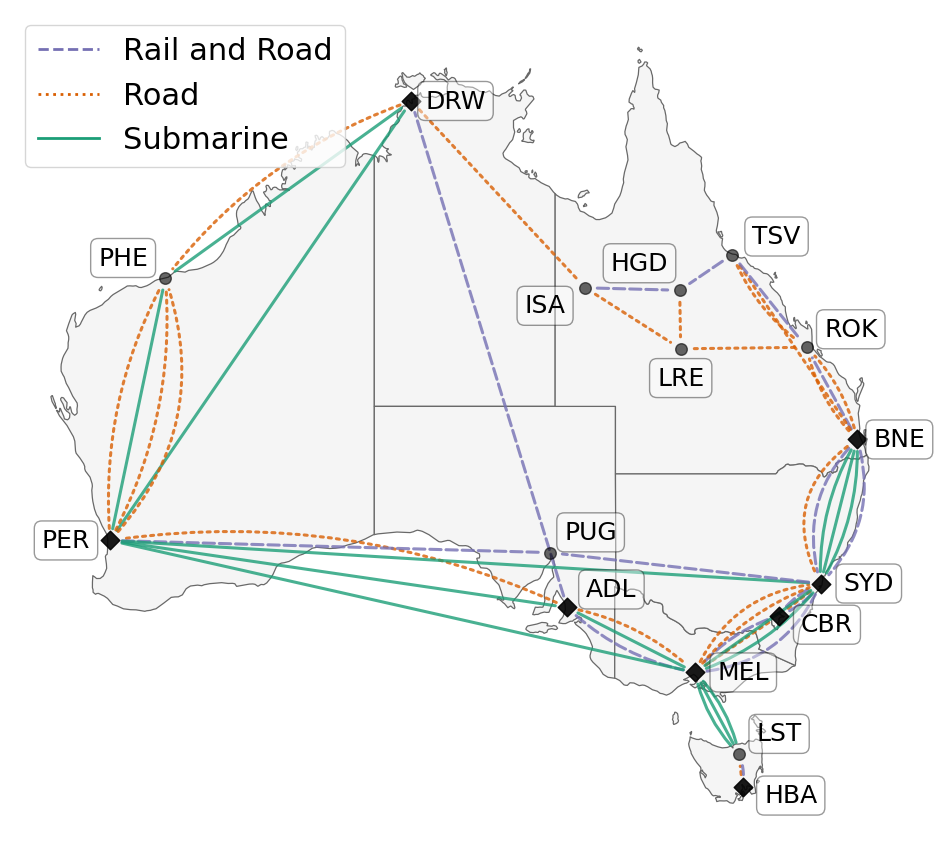

In [4]:
# SRLG corridor map: coloured by type (submarine cable, road, rail+road, etc.)
plot_srg_aus_type(G_srg, filename='srg_map_type.pdf', save_dir=FIGURES_DIR)

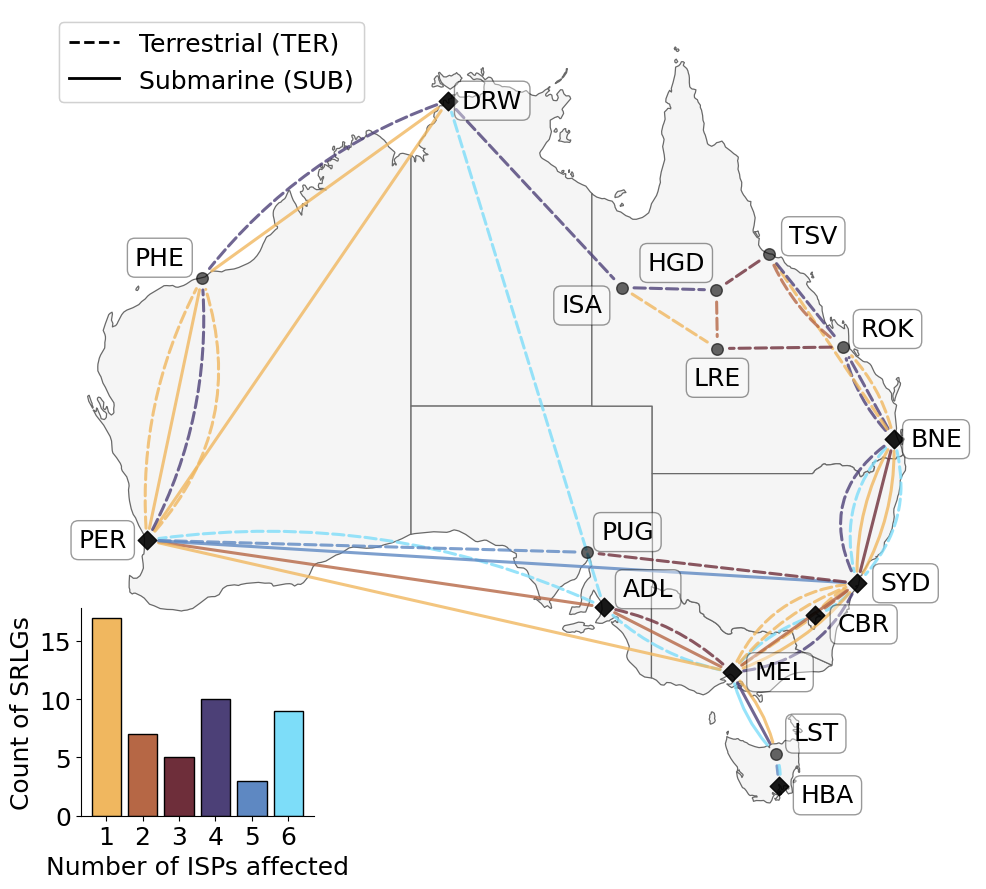

In [5]:
# SRLG map: coloured by ISP sharing degree
plot_srg_aus_deg(G_srg, srg_vs_isp_df, filename='srg_map_isp_deg.pdf', save_dir=FIGURES_DIR)

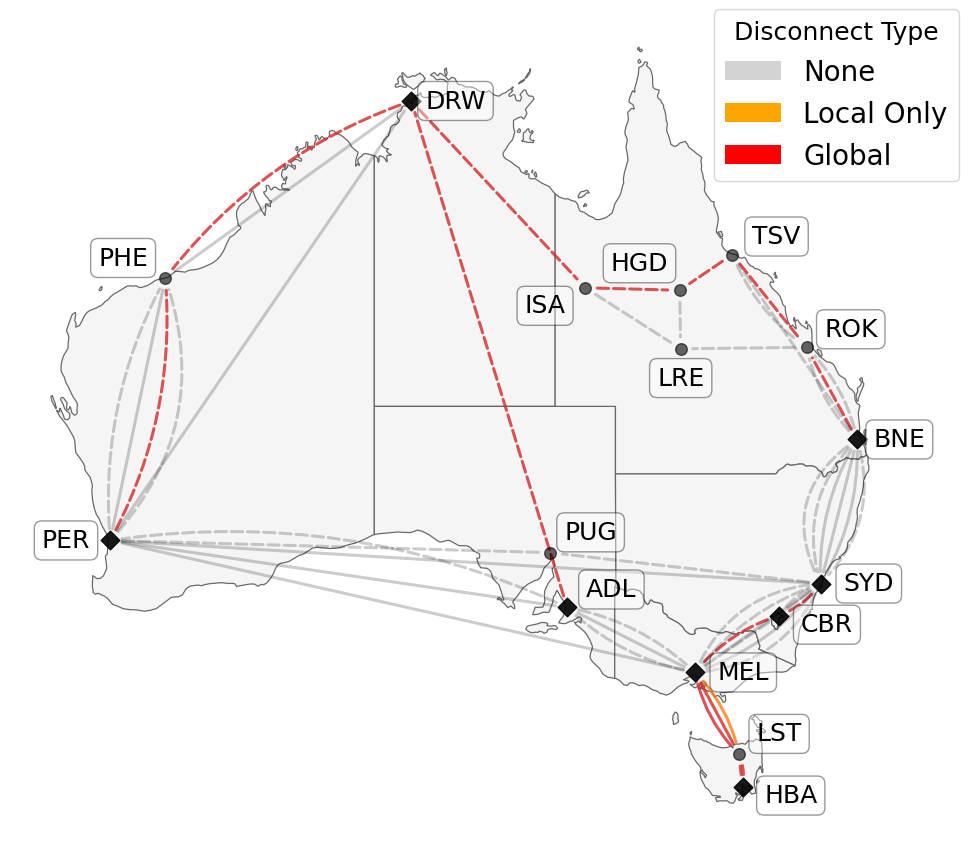

In [6]:
# SRG failure severity map
plot_srg_fail_map(G_srg, srg_sum_df, filename='srg_map_failures.pdf', save_dir=FIGURES_DIR)

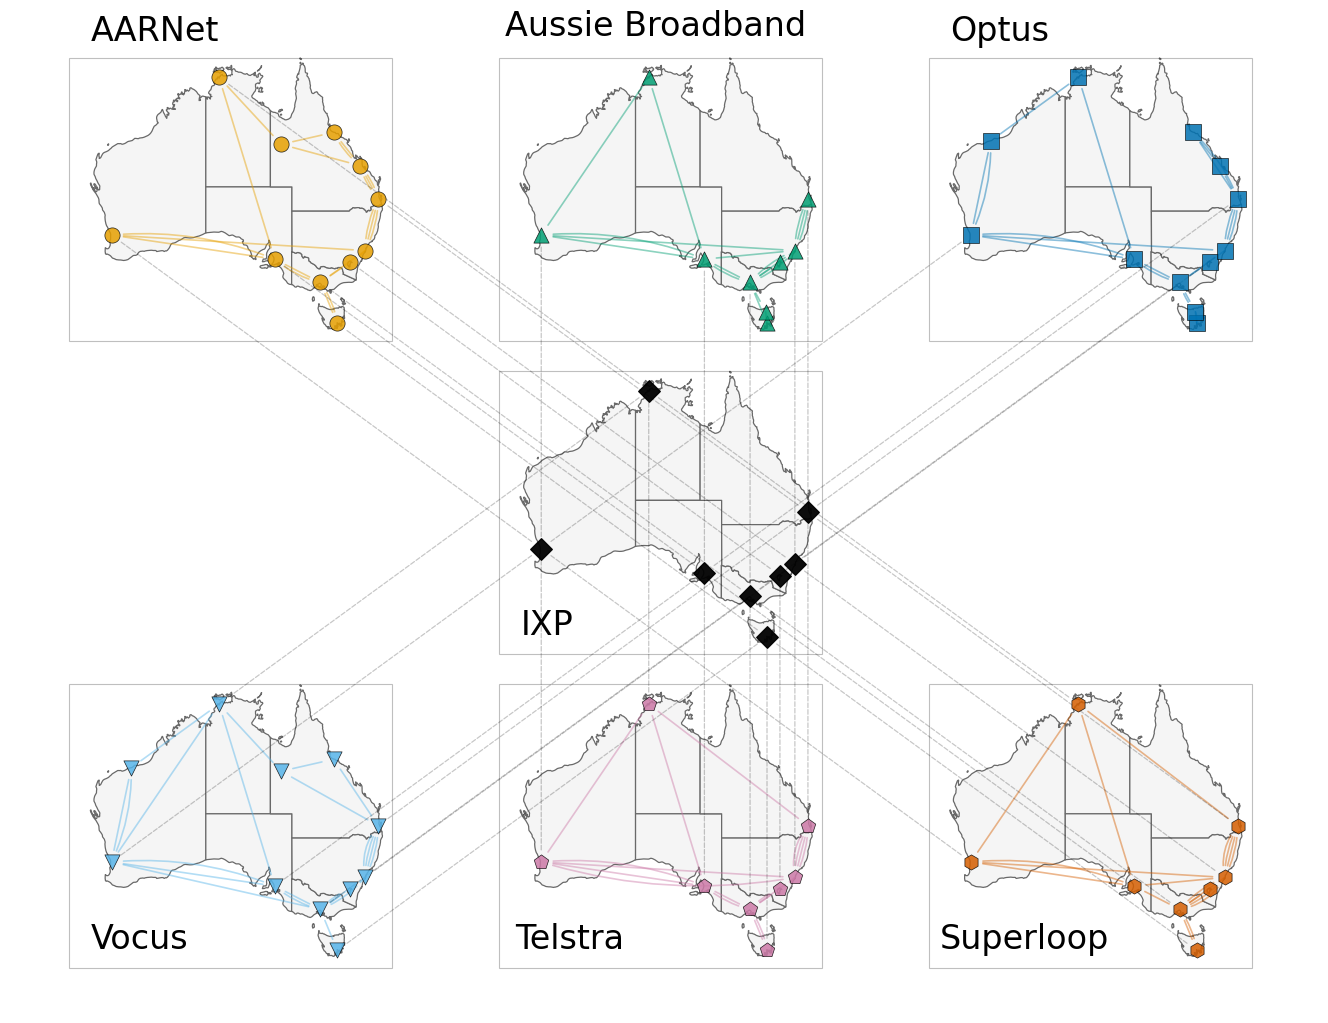

In [7]:
# Full multilayer supra-graph panel layout
plot_multilayer_panels(G_full, filename='multilayer_model_geopanels.pdf', save_dir=FIGURES_DIR)

## SRLG Sharing Statistics

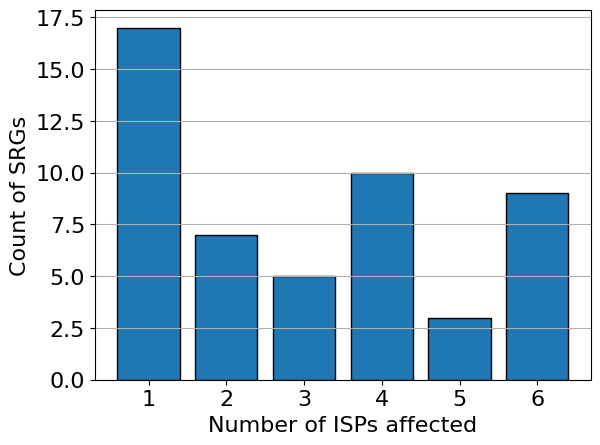

In [8]:
# Bar chart: ISPs affected per SRG — conservative
srg_isp_bar(srg_vs_isp_df, filename='srg_isp_bar.pdf', save_dir=FIGURES_DIR)

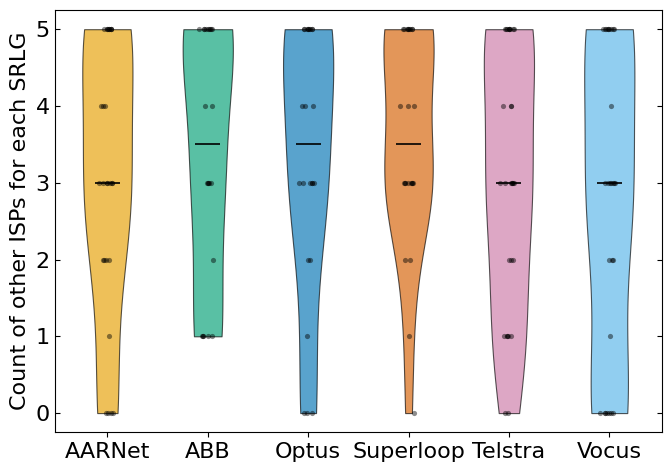

In [9]:
# Violin: shared ISPs per SRG per ISP
srg_isp_violin(srg_vs_isp_df, filename='srg_isp_violin.pdf', save_dir=FIGURES_DIR)

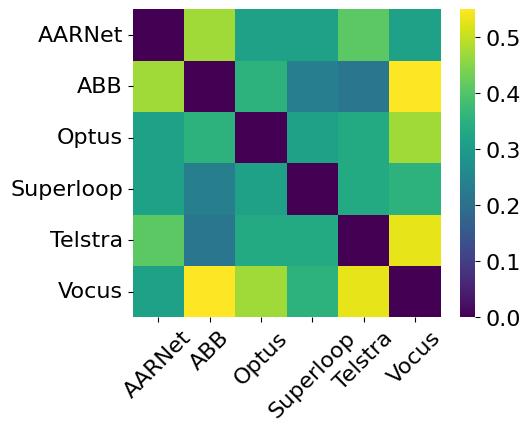

In [10]:
# Risk heatmap: pairwise ISP SRLG Hamming distance
isp_risk_heatmap(srg_vs_isp_df, filename='isp_risk_heatmap.pdf', save_dir=FIGURES_DIR)

## Failure Analysis

c:\Users\benja\Documents\UNI\MPHIL\repos\au-multilayer-model\notebooks\..\src\visualisation\plots.py:200: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


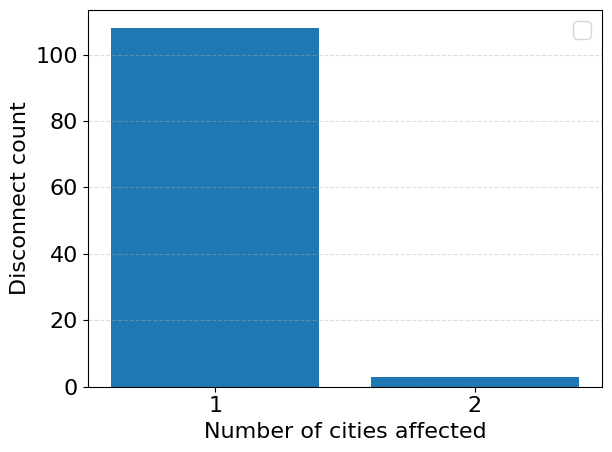

In [11]:
# Bar: cities affected per failure
city_failures(city_isp_fail_counts, filename='city_fail_bar.pdf', save_dir=FIGURES_DIR)

c:\Users\benja\Documents\UNI\MPHIL\repos\au-multilayer-model\notebooks\..\src\visualisation\plots.py:200: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


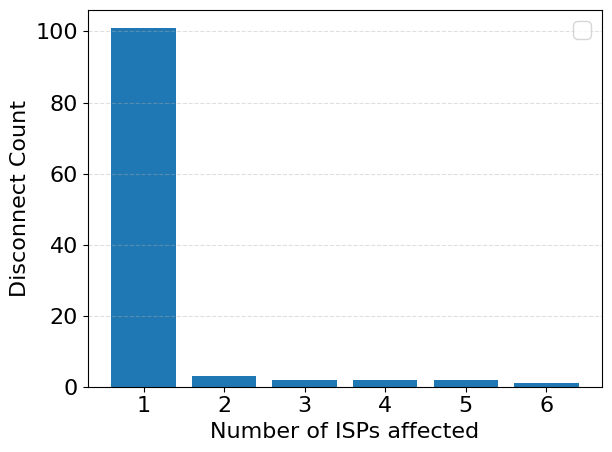

In [12]:
# Bar: ISPs affected per failure
isp_failures(city_isp_fail_counts, filename='isp_fail_bar.pdf', save_dir=FIGURES_DIR)

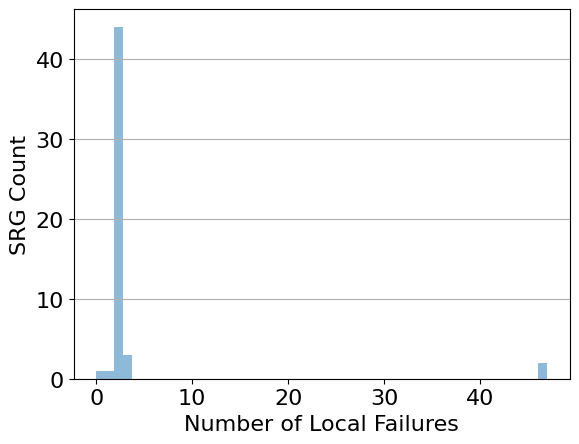

c:\Users\benja\Documents\UNI\MPHIL\repos\au-multilayer-model\notebooks\..\src\visualisation\plots.py:200: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


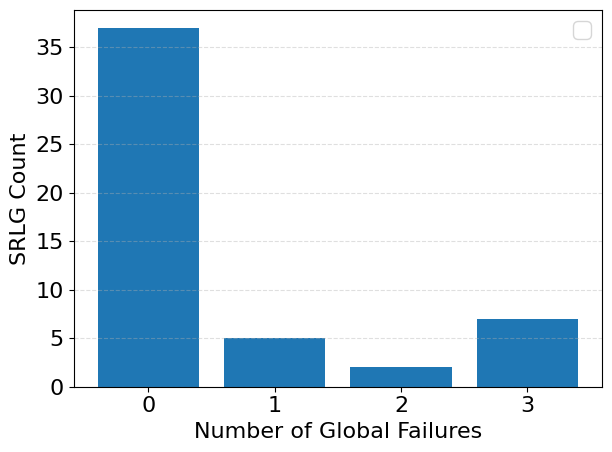

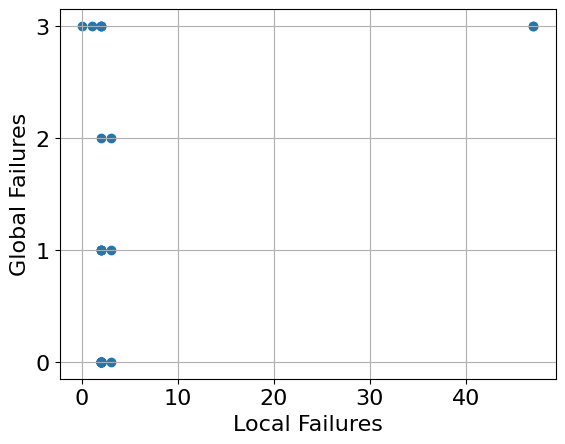

In [13]:
# Local vs global failure distributions per SRG
# local disconnect histogram
srg_local_hist(srg_sum_df, filename='local_srg.pdf', save_dir=FIGURES_DIR)

# global disconnect bar chart
srg_global_bar(srg_sum_df, filename='global_srg.pdf', save_dir=FIGURES_DIR)

# local vs global scatter plot
srg_local_global_scatter(srg_sum_df, filename='srg_local_vs_global.pdf', save_dir=FIGURES_DIR)

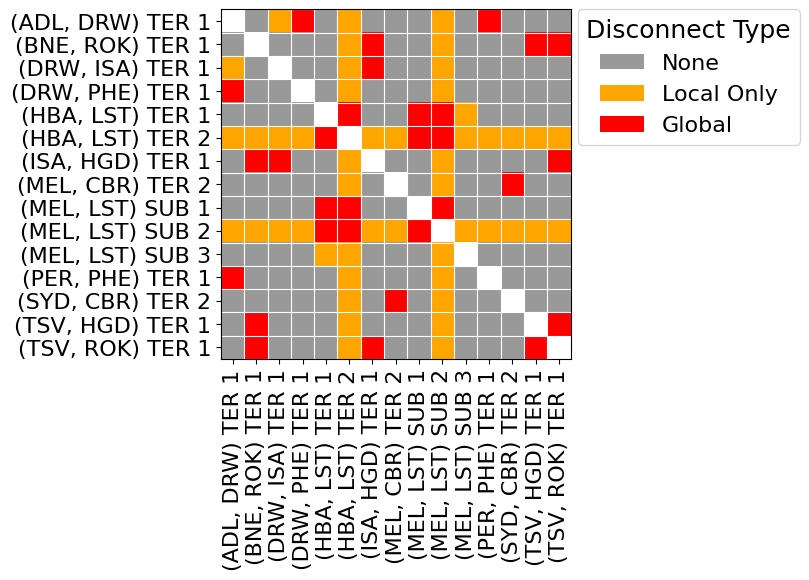

In [14]:
# SRLG pair heatmap
plot_srg_pair_heatmap(
    double_df, srg_sum_df,
    filename='srg_pair_fail_heatmap.pdf', 
    save_dir=FIGURES_DIR
)